In [39]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay



In [ ]:
df = pd.read_excel("spam.xlsx")

df["Message"] = df["Message"].astype(str)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nMessage counts:")
print(df["Category"].value_counts())

Dataset shape: (5572, 2)

First 5 rows:


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Message counts:
Category
ham     4825
spam     747
Name: count, dtype: int64


In [41]:
df["Category"] = df["Category"].map({"ham": 0, "spam": 1})

X = df["Message"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
vectorizer = CountVectorizer(stop_words="english")

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

predictions = model.predict(X_test_vec)

print(f"Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")

Accuracy: 97.49%


Confusion Matrix:
[[965   1]
 [ 27 122]]

True Negative : 965
False Positive: 1
False Negative: 27
True Positive : 122


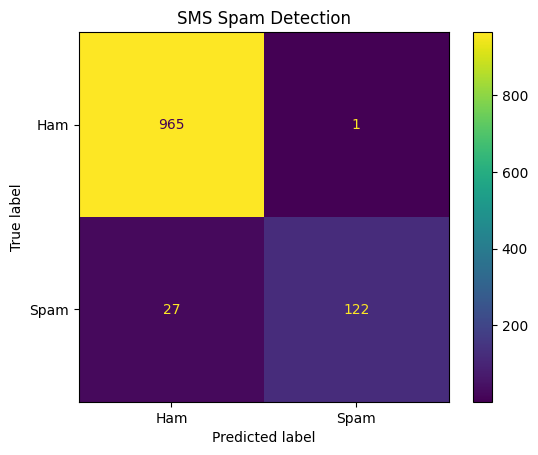

In [43]:
cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negative : {tn}")
print(f"False Positive: {fp}")
print(f"False Negative: {fn}")
print(f"True Positive : {tp}")

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
).plot()

plt.title("SMS Spam Detection")
plt.show()

In [44]:
def predict_message(message):
    vector = vectorizer.transform([message])
    prediction = model.predict(vector)[0]
    return "🚨 SPAM MESSAGE" if prediction == 1 else "📩 HAM MESSAGE"


message = input("Enter an SMS message: ")
print("\nPrediction:", predict_message(message))


Prediction: 📩 HAM MESSAGE
